In [4]:
def system(t, state):
    x, y, z = state
    dxdt = state[0]**2 + state[1]
    dydt = state[1] - state[0]
    dzdt = state[0]**3 - state[1]**3
    return [dxdt, dydt, dzdt]

In [5]:
from scipy.integrate import solve_ivp
import numpy as np

# Initial condition
x0 = np.array([.5, 0.05, 0.01])

# Time points (store solution at these times)
t_eval = np.linspace(0, 4, 4000)  # 200 snapshots

# Solve ODE
sol = solve_ivp(system, t_span=(0, 4), y0=x0, t_eval=t_eval, method='RK45')

# Extract solution
t = sol.t
snapshots = sol.y  # Shape: (3, 200)
snapshots.shape

(3, 4000)

In [6]:
X = np.array(sol.y)[:,:-1]
X_prime = np.array(sol.y)[:,1:]
X.shape, X_prime.shape

((3, 3999), (3, 3999))

In [7]:
# SVD on X
from scipy.linalg import svd
U, Sigma, Vt = svd(X, full_matrices=False)
Sigma, U.shape, Sigma.shape, Vt.shape

(array([3353.15604859,  108.78574812,   28.58240913]), (3, 3), (3,), (3, 3999))

In [8]:
np.allclose((U @ np.diag(Sigma) @ Vt), X)

True

In [9]:
r = 2

U_r = U[:, :r]
Sigma_r = Sigma[:r]
Vt_r = Vt[:r, :]

Sigma, Sigma_r, np.sum(Sigma_r**2)/np.sum(Sigma**2)

(array([3353.15604859,  108.78574812,   28.58240913]),
 array([3353.15604859,  108.78574812]),
 np.float64(0.9999274225438324))

In [10]:
A_tilde = U_r.T @ X_prime @ Vt_r.T @ np.linalg.inv(np.diag(Sigma_r))
A_tilde

array([[ 1.00180077e+00, -4.55569788e-04],
       [-7.17025566e-05,  1.00068399e+00]])

In [11]:
Lambda, W = np.linalg.eig(A_tilde)
Phi = U_r @ W
Phi, W # modes in orig space

(array([[ 0.00241601, -0.35880564],
        [ 0.00341991, -0.87876191],
        [ 0.99999123,  0.31469989]]),
 array([[ 0.99804599,  0.36960617],
        [-0.06248355,  0.92918851]]))

In [12]:
b, residuals, rank, s = np.linalg.lstsq(Phi, x0, rcond=None)
b.shape

(2,)

In [13]:
def dmd_predict(k, Phi, Lambda, b):
    x_pred = Phi @ (Lambda**k * b)
    return np.real(x_pred).flatten()  # Flatten to 1D!

In [14]:
print("x0:", x0.flatten())
print("x_pred_0:", dmd_predict(0, Phi, Lambda, b).flatten())
print("Phi @ b:", np.real(Phi @ b).flatten())

x0: [0.5  0.05 0.01]
x_pred_0: [0.08907438 0.21793414 0.01041848]
Phi @ b: [0.08907438 0.21793414 0.01041848]


In [15]:
print("U_r shape:", U_r.shape)
print("W shape:", W.shape)
print("Phi shape:", Phi.shape)
print("Phi dtype:", Phi.dtype)

U_r shape: (3, 2)
W shape: (2, 2)
Phi shape: (3, 2)
Phi dtype: float64


In [16]:
r = 3

U_r = U[:, :r]
Sigma_r = Sigma[:r]
Vt_r = Vt[:r, :]

# Recompute A_tilde, eigendecomp, Phi, b
A_tilde = U_r.T @ X_prime @ Vt_r.T @ np.linalg.inv(np.diag(Sigma_r))
Lambda, W = np.linalg.eig(A_tilde)
Phi = U_r @ W

x0 = x0.flatten()
b, _, _, _ = np.linalg.lstsq(Phi, x0, rcond=None)
b = b.flatten()
residual = x0 - (Phi @ b)
print("Residual norm (r=3):", np.linalg.norm(residual))
sol.y[:, 0:1], x0

Residual norm (r=3): 2.361837320389646e-16


(array([[0.5 ],
        [0.05],
        [0.01]]),
 array([0.5 , 0.05, 0.01]))

In [17]:
# Predict first 10 snapshots
k_values = np.arange(0, 10)
x_dmd_pred = np.array([dmd_predict(k, Phi, Lambda, b) for k in k_values]).T

# Compare with true snapshots
x_true = sol.y[:, :10]

print("DMD predictions (first 10 steps):")
print(x_dmd_pred)
print("\nTrue snapshots:")
print(x_true)
print("\nError:")
print(np.linalg.norm(x_dmd_pred - x_true, axis=0))

DMD predictions (first 10 steps):
[[0.5        0.49981421 0.49962824 0.49944209 0.49925576 0.49906925
  0.49888257 0.4986957  0.49850866 0.49832143]
 [0.05       0.04954981 0.04909936 0.04864864 0.04819766 0.04774641
  0.0472949  0.04684313 0.04639108 0.04593878]
 [0.01       0.01083201 0.01166535 0.01250002 0.01333602 0.01417336
  0.01501203 0.01585204 0.01669339 0.01753609]]

True snapshots:
[[0.5        0.5003     0.50059985 0.50089955 0.50119909 0.50149848
  0.50179772 0.50209681 0.50239574 0.50269451]
 [0.05       0.04954951 0.04909827 0.04864628 0.04819354 0.04774005
  0.0472858  0.04683079 0.04637504 0.04591852]
 [0.01       0.01012502 0.01025027 0.01037575 0.01050145 0.01062739
  0.01075355 0.01087995 0.01100657 0.01113342]]

Error:
[2.08462955e-16 8.57806281e-04 1.71653436e-03 2.57618612e-03
 3.43676342e-03 4.29826817e-03 5.16070223e-03 6.02406751e-03
 6.88836591e-03 7.75359932e-03]


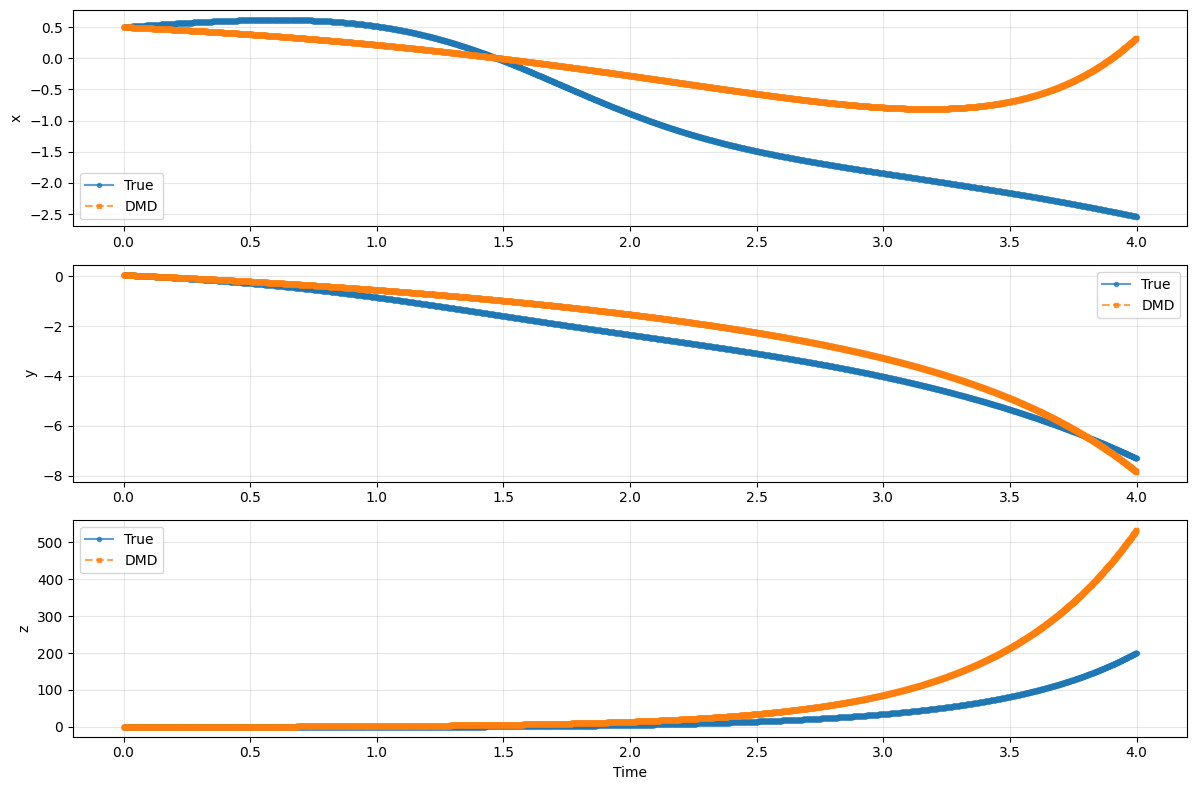

Error at step 10: 0.0086
Error at step 50: 0.0441
Error at step 100: 0.0907


In [19]:
import matplotlib.pyplot as plt
# Predict longer horizon
k_long = np.arange(0, 4000)
x_dmd_long = np.array([dmd_predict(k, Phi, Lambda, b) for k in k_long])
# Now x_dmd_long is (150, 3) — each row is a snapshot

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i in range(3):
    axes[i].plot(sol.t, sol.y[i], 'o-', label='True', markersize=3, alpha=0.7)
    axes[i].plot(k_long * 4/4000, x_dmd_long[:, i], 's--', label='DMD', markersize=3, alpha=0.7)
    axes[i].set_ylabel(['x', 'y', 'z'][i])
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

# Error
errors = np.linalg.norm(x_dmd_long - sol.y.T, axis=1)
print(f"Error at step 10: {errors[10]:.4f}")
print(f"Error at step 50: {errors[50]:.4f}")
print(f"Error at step 100: {errors[100]:.4f}")

In [20]:
threshold = 0.1
steps_acceptable = np.where(errors > threshold)[0][0]
print(f"DMD breaks down after ~{steps_acceptable} steps (error > 0.1)")
print(f"Time horizon: {steps_acceptable * 0.001:.2f} seconds")

DMD breaks down after ~110 steps (error > 0.1)
Time horizon: 0.11 seconds


# Complete DMD prediction function

In [68]:
def dmd_pred(snapshots,energy):
    X = np.array(snapshots)[:,:-1]
    X_prime = np.array(snapshots)[:,1:]
    U, Sigma, Vt = svd(X, full_matrices=False)
    print(f"Sigma :{Sigma}")
    e = Sigma**2
    cumulative_energy = np.cumsum(e)/np.sum(e)
    r = np.searchsorted(cumulative_energy,energy) +1
    print(f"rank chosen: {r}")
    U_r = U[:, :r]
    Sigma_r = Sigma[:r]
    Vt_r = Vt[:r, :]
    
    A_tilde = U_r.T @ X_prime @ Vt_r.T @ np.linalg.inv(np.diag(Sigma_r))

    Lambda, W = np.linalg.eig(A_tilde)
    Phi = X_prime @ Vt_r.T @ np.linalg.inv(np.diag(Sigma_r)) @ W
    Phi_classical = U_r @ W
    
    b, _, _, _ = np.linalg.lstsq(Phi, snapshots[:,0:1], rcond=None)
    b = b.flatten()
    def dmd_predict(k):
        x_pred = Phi @ (Lambda**k * b)
        return np.real(x_pred).flatten()  
    return dmd_predict, Phi, Phi_classical, Lambda

In [85]:
def dmd_plot(energy, t, steps, system, x0, noise_dim = 0):

    # Time points (store solution at these times)
    t_eval = np.linspace(0, t, steps)

    # Solve ODE
    sol = solve_ivp(system, t_span=(0, t), y0=x0, t_eval=t_eval, method='RK45')
    snapshots = sol.y
    if noise_dim > 0:
        np.random.seed(42)
        noise_level = 0.02  # Adjust if needed
        noise = np.random.normal(0, noise_level, (noise_dim, steps))
        snapshots = np.vstack((sol.y,noise))

    pred, Phi, Phi_classical, Lambda = dmd_pred(snapshots,energy)
    print(f"Phi: {Phi}; \nPhi_classical: {Phi_classical}; \nLambda: {Lambda}")
    k_long = np.arange(0, steps)
    x_dmd_long = np.array([pred(k) for k in k_long])
    
    # Plot
    fig, axes = plt.subplots(len(x0)+noise_dim, 1, figsize=(12, 8))
    label = [f"x{i}" for i in range(len(x0))] + ['noise']*noise_dim
    for i in range(len(x0)+noise_dim):
        axes[i].plot(sol.t, snapshots[i], 'o-', label='True', markersize=3, alpha=0.7)
        axes[i].plot(k_long * (t/steps), x_dmd_long[:, i], 's--', label='DMD', markersize=3, alpha=0.7)
        axes[i].set_ylabel(label[i])
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time')
    plt.tight_layout()
    plt.show()

Sigma :[3353.15604859  108.78574812   28.58240913]
rank chosen: 2
Phi: [[ 0.00243329 -0.35917738]
 [ 0.00342092 -0.8792821 ]
 [ 1.00182049  0.31490631]]; 
Phi_classical: [[ 0.00241601 -0.35880564]
 [ 0.00341991 -0.87876191]
 [ 0.99999123  0.31469989]]; 
Lambda: [1.00182929 1.00065547]


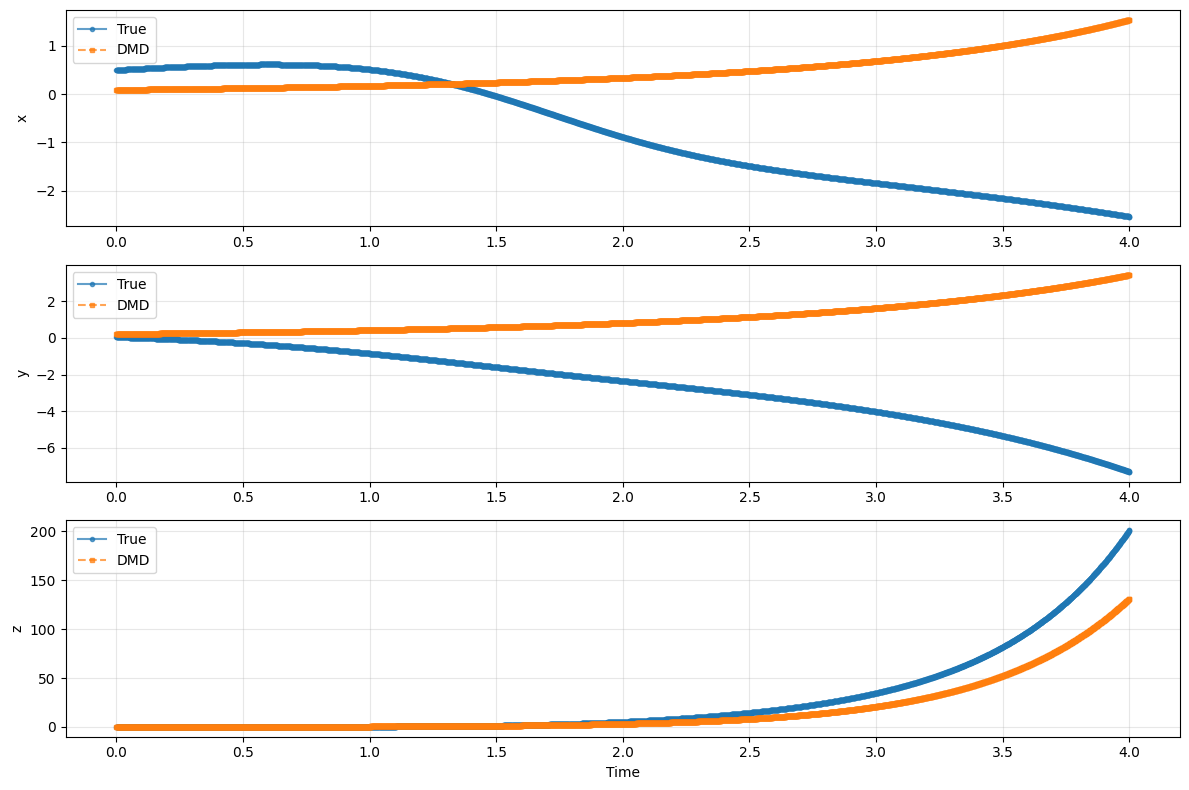

In [72]:
dmd_plot(0.999,4,4000,system,x0)

# Now with 20D, of which 3D are important

In [39]:
x0 = np.array([.5, 0.05, 0.01])

# Time points (store solution at these times)
t_eval = np.linspace(0, 3, 300)  # 200 snapshots

# Solve ODE
sol = solve_ivp(system, t_span=(0, 3), y0=x0, t_eval=t_eval, method='RK45')
snapshots=sol.y
np.random.seed(42)
noise_level = 0.02  # Adjust if needed
noise_7d = np.random.normal(0, noise_level, (7, 300))

# Stack to 10D
snapshots_10d = np.vstack([snapshots, noise_7d])

In [40]:

x0_10d = snapshots_10d[:, 0:1]
# DMD predictor with 99.5% energy
predictor = dmd_pred(snapshots_10d, 0.999)

# Predict first 50 steps
k_range = np.arange(0, 200)
x_dmd = np.array([predictor(k) for k in k_range])

# Compare with true 10D snapshots
x_true_10d = snapshots_10d.T

errors_10d = np.linalg.norm(x_dmd - x_true_10d[:200], axis=1)

print("Error at step 0:", errors_10d[0])
print("Error at step 20:", errors_10d[20])
print("Error at step 50:", errors_10d[49])


Sigma :[185.03158347  16.71088375   7.81027691   0.37256075   0.36113349
   0.34375601   0.33493499   0.33241789   0.3154398    0.31110118]
rank chosen: 3
Error at step 0: 0.05013577473644981
Error at step 20: 0.14873342851374585
Error at step 50: 0.36122893219803526


Sigma :[1050.57900785   34.25566058    9.0320032 ]
rank chosen: 3
Phi: [[-0.00551941+0.j         -0.52129559+0.15466604j -0.52129559-0.15466604j]
 [ 0.00660571+0.j         -0.69707833-0.05979559j -0.69707833+0.05979559j]
 [-1.01852698+0.j          0.46029301-0.09234207j  0.46029301+0.09234207j]]; 
Phi_classical: [[-0.00541881+0.j         -0.51941103+0.15571675j -0.51941103-0.15571675j]
 [ 0.00648532+0.j         -0.69531502-0.05765124j -0.69531502+0.05765124j]
 [-0.99996429+0.j          0.4587545 -0.09339246j  0.4587545 +0.09339246j]]; 
Lambda: [1.01856336+0.j         1.00277263+0.00285411j 1.00277263-0.00285411j]


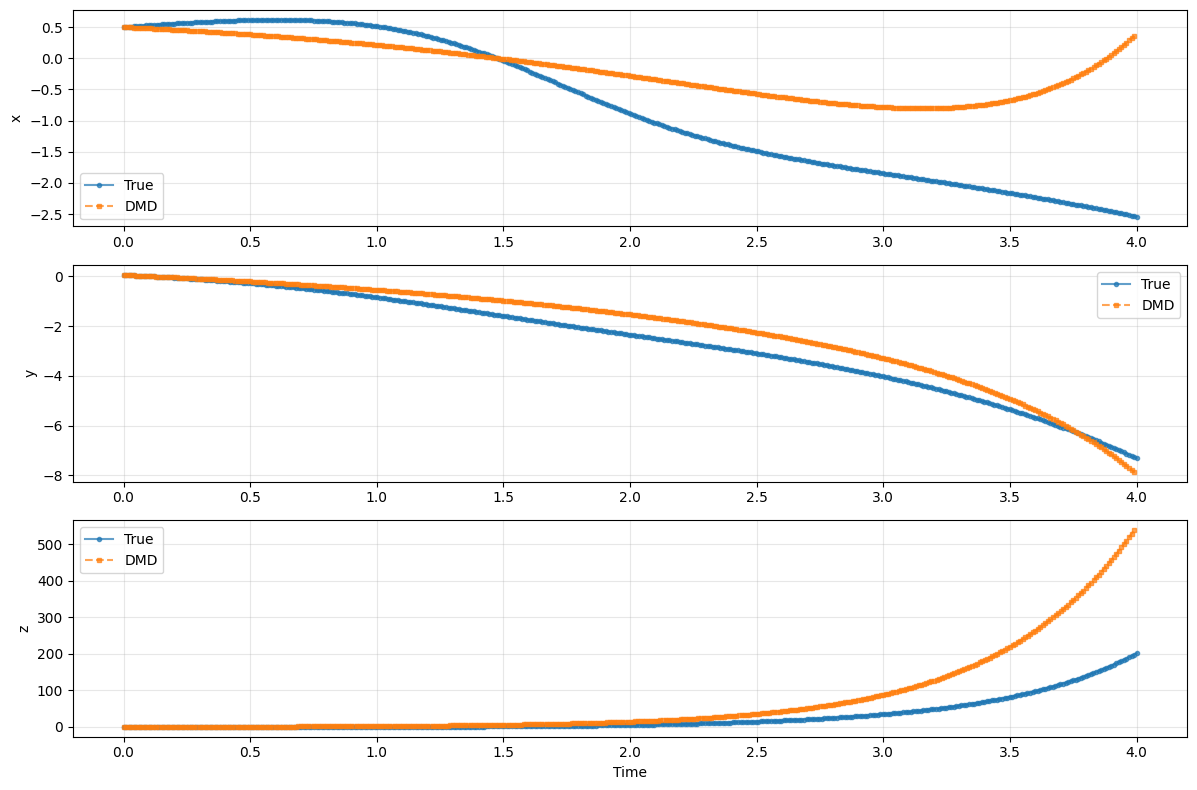

In [74]:
dmd_plot(0.99999,4,400,system,x0)

# Experimente mit verschiedenen 

Sigma :[3.7547143  0.21767511 0.16622386 0.14414219 0.1262283  0.1114562
 0.09319779 0.00751249]
rank chosen: 3
Phi: [[-0.74466656 -0.54965509  0.0008898 ]
 [-0.51891789  0.40646554 -0.00178459]
 [-0.29493593  0.58706623  0.00560375]
 [ 0.03309859 -0.19899239  0.15454   ]
 [ 0.00243994 -0.02955847 -0.15093158]
 [ 0.00103278 -0.01078644  0.21483866]
 [-0.0083356   0.02568728  0.09878511]
 [-0.00086978 -0.05617457  0.06122657]]; 
Phi_classical: [[-7.83014730e-01 -5.79473919e-01  3.92244090e-04]
 [-5.40369378e-01  4.22998847e-01 -1.94112109e-03]
 [-3.03945769e-01  6.05430835e-01  5.77648456e-03]
 [ 4.61991197e-02 -3.00291979e-01 -1.95513952e-01]
 [ 7.50195010e-03 -6.21510623e-02  3.56183338e-01]
 [-1.19371320e-02  8.60254386e-02 -5.39277066e-01]
 [-1.02112451e-02  3.37430857e-02 -1.04974817e-01]
 [ 8.27250228e-03 -1.27115920e-01 -7.30089699e-01]]; 
Lambda: [ 0.95474978  0.91454569 -0.25486626]


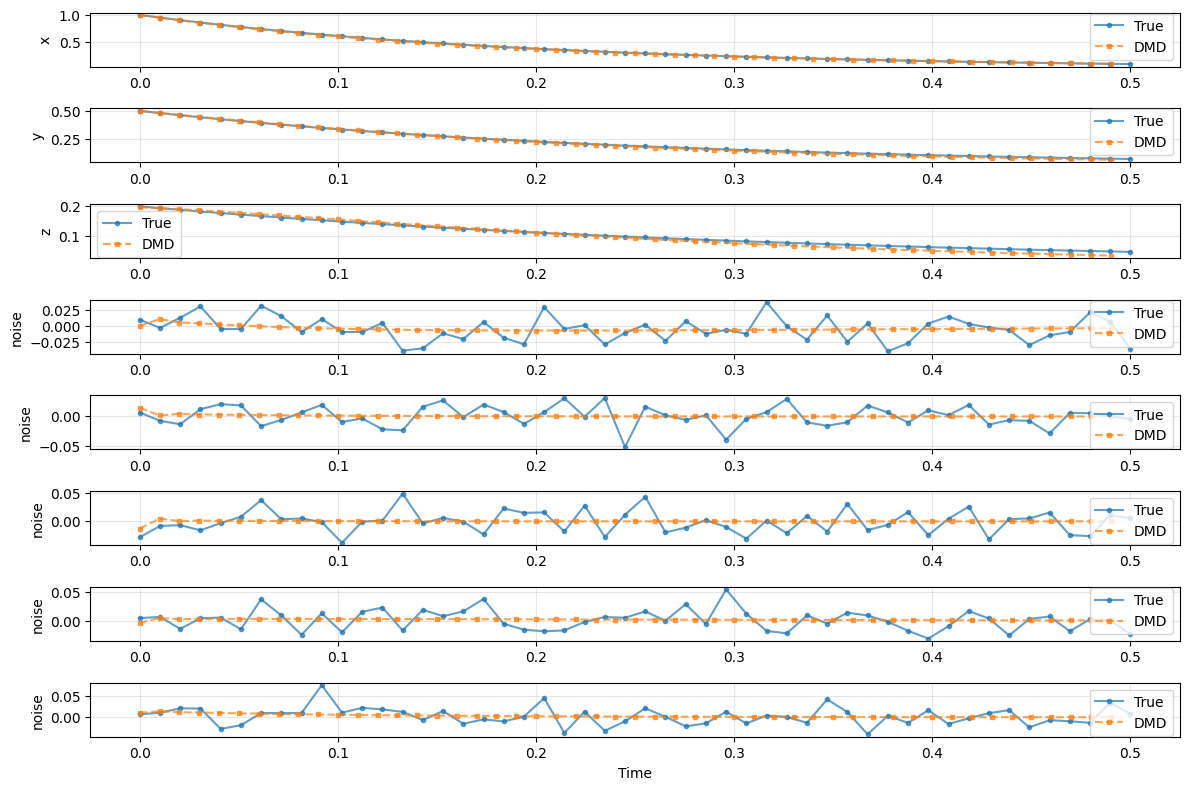

In [81]:
def fast_decay(t, state):
    x, y, z = state
    dxdt = -5*x + 0.1*y
    dydt = -4*y + 0.05*z
    dzdt = -3*z + 0.02*x
    return [dxdt, dydt, dzdt]

x0 = np.array([1.0, 0.5, 0.2])
t = 0.5
steps = 50

# DMD Parameters
noise_dims = 5  # 3 echte + 7 Rauschen = 10D
energy_threshold = 0.995  # 99%

dmd_plot(energy_threshold,t,steps,fast_decay,x0,noise_dims)

Sigma :[11.50340144 10.82488386  1.07187531  0.81161472  0.32332509  0.29865304
  0.28456266  0.26111535  0.24508981  0.23336981]
rank chosen: 3
Phi: [[ 5.33079588e-01+3.09490089e-01j  5.33079588e-01-3.09490089e-01j
   3.17711779e-01+0.00000000e+00j]
 [-3.17217758e-01+5.51552507e-01j -3.17217758e-01-5.51552507e-01j
   3.05797506e-01+0.00000000e+00j]
 [ 3.37893576e-01+5.42953438e-02j  3.37893576e-01-5.42953438e-02j
  -4.54662379e-01+0.00000000e+00j]
 [-4.53691863e-02+3.09717267e-01j -4.53691863e-02-3.09717267e-01j
  -7.66319397e-01+0.00000000e+00j]
 [-5.68694602e-04+2.01422278e-04j -5.68694602e-04-2.01422278e-04j
  -5.40534285e-03+0.00000000e+00j]
 [ 6.06114909e-04+2.19867884e-03j  6.06114909e-04-2.19867884e-03j
   3.83787034e-02+0.00000000e+00j]
 [-6.75100690e-04+6.28732963e-04j -6.75100690e-04-6.28732963e-04j
   2.45940300e-02+0.00000000e+00j]
 [ 4.58253181e-05+4.22041255e-04j  4.58253181e-05-4.22041255e-04j
   3.12330490e-02+0.00000000e+00j]
 [-4.99290128e-04+1.23944607e-03j -4.99290

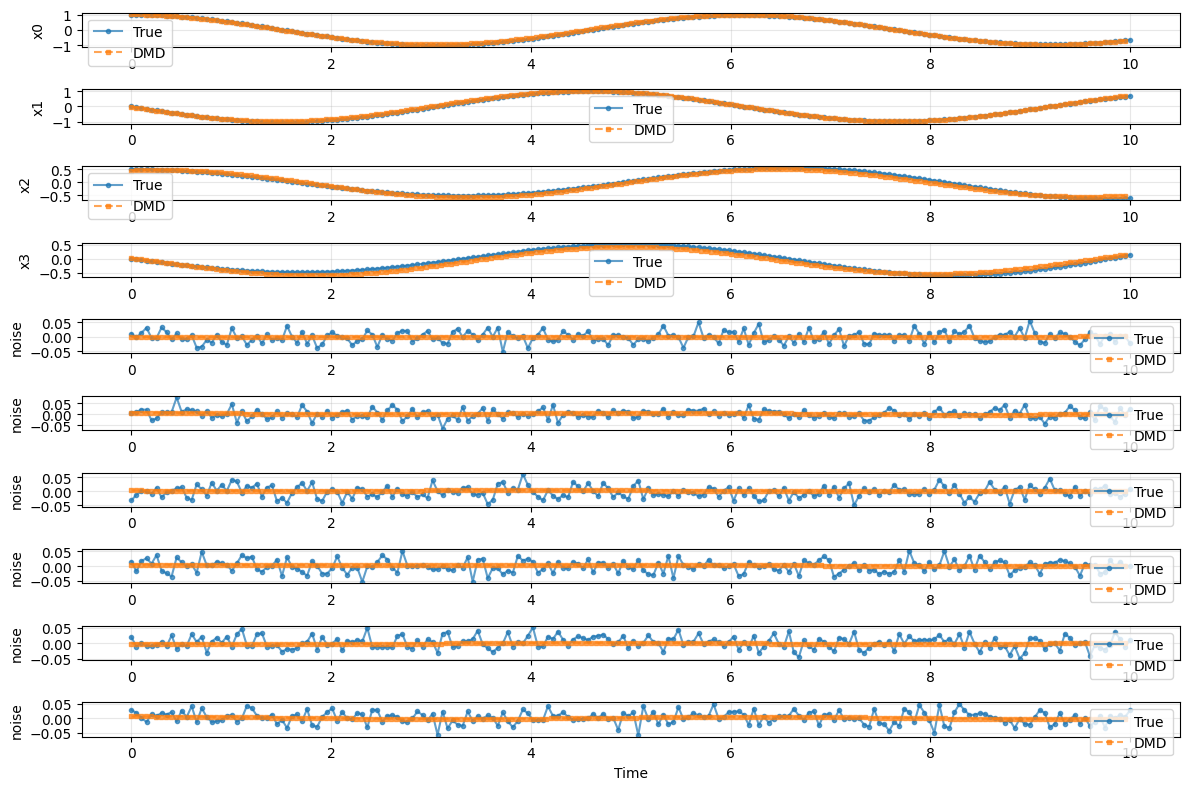

In [86]:
def coupled_oscillators(t, state):
    x1, v1, x2, v2 = state
    dx1dt = v1
    dv1dt = -x1 - 0.1*(x1 - x2)
    dx2dt = v2
    dv2dt = -x2 - 0.1*(x2 - x1)
    return [dx1dt, dv1dt, dx2dt, dv2dt]

x0 = np.array([1.0, 0.0, 0.5, 0.0])
t = 10
steps = 200

# DMD Parameters
noise_dims = 6  # 4 echte + 6 Rauschen = 10D
energy_threshold = 0.995  # 99.5%

dmd_plot(energy_threshold,t,steps,coupled_oscillators,x0,noise_dims)

Sigma :[5.81080794 5.13498237 0.24746713 0.2251681  0.21317468 0.19769809
 0.17960642 0.17077788 0.15806103 0.14512342]
rank chosen: 3
Phi: [[ 6.99077465e-01+1.81667942e-01j  6.99077465e-01-1.81667942e-01j
   2.50005902e-04+0.00000000e+00j]
 [ 2.09352831e-01-6.71560107e-01j  2.09352831e-01+6.71560107e-01j
   6.76118806e-03+0.00000000e+00j]
 [ 5.84579847e-04+1.76939167e-03j  5.84579847e-04-1.76939167e-03j
   1.13776082e-01+0.00000000e+00j]
 [-2.44737266e-03+1.07603959e-03j -2.44737266e-03-1.07603959e-03j
  -9.80588572e-02+0.00000000e+00j]
 [ 2.79302385e-03-4.77886204e-04j  2.79302385e-03+4.77886204e-04j
  -4.76530128e-04+0.00000000e+00j]
 [ 6.59902606e-04+1.96227370e-03j  6.59902606e-04-1.96227370e-03j
   1.98055032e-02+0.00000000e+00j]
 [ 2.94162025e-03-3.83486005e-04j  2.94162025e-03+3.83486005e-04j
  -9.20781879e-02+0.00000000e+00j]
 [ 8.66078692e-04+2.25255951e-03j  8.66078692e-04-2.25255951e-03j
   1.52607228e-01+0.00000000e+00j]
 [ 2.57018944e-03-6.27480379e-04j  2.57018944e-03+6.

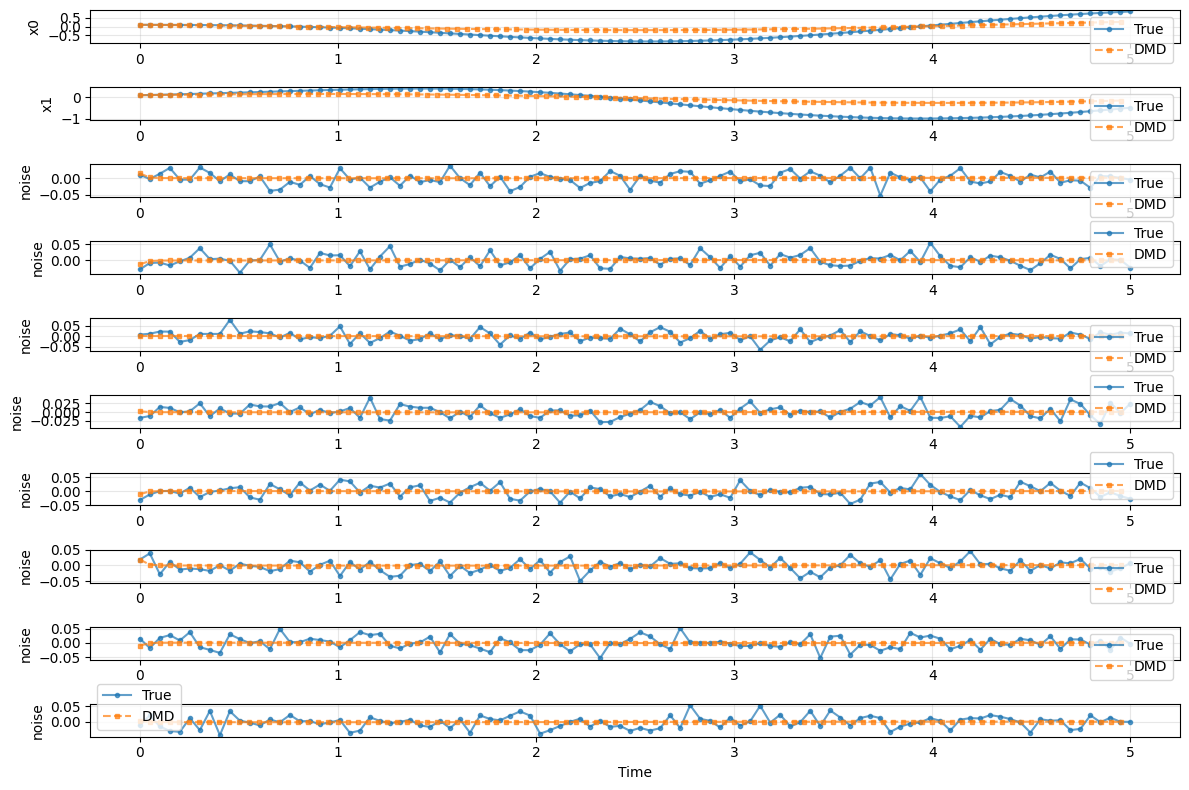

In [88]:
def limit_cycle_unstable(t, state):
    x, y = state
    r2 = x**2 + y**2
    dxdt = (1 - r2) * x - y
    dydt = (1 - r2) * y + x
    return [dxdt, dydt]

x0 = np.array([0.1, 0.1])
t = 5
steps = 100

# DMD Parameters
noise_dims = 8  # 2 echte + 8 Rauschen = 10D
energy_threshold = 0.995  # 99.5%

dmd_plot(energy_threshold,t,steps,limit_cycle_unstable,x0,noise_dims)